In [1]:
import pandas as pd
import numpy as np
from os import getcwd, listdir, path
import matplotlib.pyplot as plt
import sys
import ast
from glob import glob

import fitness.data_generating_process as dgp
import fitness.soga_fitness_SCM as soga_fitness_SCM
import fitness.interventions as interventions

In [10]:
# Read all pareto_fitness.txt files under results/causal_skills_tests and build aggregated stats
ex_name = 'chain_fixed_interventions'
program = 'chain'
base_dir = path.join('..', 'results', ex_name)
pattern = path.join(base_dir, '**', 'pareto_fitness.txt')
files = glob(pattern, recursive=True)

records = []
for fp in files:
    df = pd.read_csv(fp, sep='\t', header=None, names=['generation', 'fitness_class'])
    df[['fitness', 'class']] = pd.DataFrame(
        df['fitness_class'].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x
        ).tolist(),
        index=df.index,
    )
    df['run'] = path.basename(path.dirname(fp))
    records.append(df[['generation', 'fitness', 'class', 'run']])
    # drop duplicate entries
    records[-1] = records[-1].drop_duplicates(subset=['generation', 'fitness', 'class', 'run'])

if records:
    pareto_fitness = pd.concat(records, ignore_index=True)
else:
    pareto_fitness = pd.DataFrame(columns=['generation', 'fitness', 'class', 'run'])

# Aggregate mean/std per generation and class and median and interquartile range
pareto_stats = (
    pareto_fitness
    .groupby(['generation', 'class'])['fitness']
    .agg(['mean', 'std', 'count', np.median, lambda x: np.percentile(x, 25), lambda x: np.percentile(x, 75)])
    .reset_index()
    .rename(columns={'mean': 'fitness_mean', 'std': 'fitness_std', 'count': 'n', 'median': 'fitness_median', '<lambda_0>': 'fitness_q1', '<lambda_1>': 'fitness_q3'})
)
pareto_stats['fitness_std'] = pareto_stats['fitness_std'].fillna(0)

print(f"Found {len(files)} pareto_fitness.txt files")
print(pareto_stats.head())
print(f"\nGenerations: {pareto_stats['generation'].min() if not pareto_stats.empty else 'NA'} to {pareto_stats['generation'].max() if not pareto_stats.empty else 'NA'}")

# Save aggregated stats to a new file csv named ex_name + '_pareto_stats.csv' and
# saved in ../results/synhesis
output_fp = path.join('..', 'results', 'synthesis', f'{ex_name}_pareto_stats.csv')
pareto_stats.to_csv(output_fp, index=False)

Found 10 pareto_fitness.txt files
   generation  class  fitness_mean  fitness_std  n  fitness_median  \
0           0     -3   -169.092866     0.008439  2     -169.092866   
1           0     -2   -176.641075    15.220890  5     -165.538054   
2           0     -1  -1139.803966  1521.267586  7     -256.412016   
3           0      0   -268.914790     0.344851  3     -268.910428   
4           1     -3   -169.092866     0.008439  2     -169.092866   

    fitness_q1  fitness_q3  
0  -169.095850 -169.089883  
1  -193.305662 -165.522966  
2 -1811.535730 -247.468292  
3  -269.086114 -268.741284  
4  -169.095850 -169.089883  

Generations: 0 to 300


/tmp/ipykernel_54624/2776592644.py:31: FutureWarning: The provided callable <function median at 0x72ee949a6200> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  .agg(['mean', 'std', 'count', np.median, lambda x: np.percentile(x, 25), lambda x: np.percentile(x, 75)])


In [11]:
# print the fitness values for generation 250 and class 0 for all the 10 runs, one value for each run
gen = 250
cls = 0
gen_cls_fitness = pareto_fitness[(pareto_fitness['generation'] == gen) & (pareto_fitness['class'] == cls)]
print(f"\nFitness values for generation {gen} and class {cls}:")
for run in gen_cls_fitness['run'].unique():
    run_fitness = gen_cls_fitness[gen_cls_fitness['run'] == run]['fitness'].values
    if len(run_fitness) > 0:
        print(f"Run {run}: {run_fitness[0]}")
    else:
        print(f"Run {run}: No data")

# print median and interquartile range for generation 250 and class 0 using 1 value for each run, so total 10 values
gen = 250
cls = 0
gen_cls_fitness = pareto_fitness[(pareto_fitness['generation'] == gen) & (pareto_fitness['class'] == cls)]
fitness_values = []
for run in gen_cls_fitness['run'].unique():
    run_fitness = gen_cls_fitness[gen_cls_fitness['run'] == run]['fitness'].values
    if len(run_fitness) > 0:
        fitness_values.append(run_fitness[0])
if fitness_values:  
    median_fitness = np.median(fitness_values)
    q1 = np.percentile(fitness_values, 25)
    q3 = np.percentile(fitness_values, 75)
    iqr = q3 - q1
    print(f"\nMedian fitness for generation {gen} and class {cls}: {median_fitness}")
    print(f"Interquartile range (IQR) for generation {gen} and class {cls}: {iqr} (Q1: {q1}, Q3: {q3})")


Fitness values for generation 250 and class 0:
Run e243-012.eduroam.tuwien.ac.at_26_1_15_103419_735598_91557_3: -96.1033706962365
Run e243-012.eduroam.tuwien.ac.at_26_1_14_160752_117847_55843_2: -93.22717169463222
Run e243-012.eduroam.tuwien.ac.at_26_1_15_103419_720614_91554_0: -94.25025423210498
Run e243-012.eduroam.tuwien.ac.at_26_1_15_103419_662996_91556_2: -90.7943460492376
Run e243-012.eduroam.tuwien.ac.at_26_1_14_111738_992776_17273_2: -88.26326890313425
Run e243-012.eduroam.tuwien.ac.at_26_1_14_160752_139168_55845_4: -96.14262418693784
Run e243-012.eduroam.tuwien.ac.at_26_1_15_103419_728198_91559_4: -102.37967436305678
Run e243-012.eduroam.tuwien.ac.at_26_1_14_111738_955925_17271_0: -97.43547442034291
Run e243-012.eduroam.tuwien.ac.at_26_1_14_160752_176959_55844_3: -96.52037801072326
Run e243-012.eduroam.tuwien.ac.at_26_1_14_160752_205531_55840_0: -97.62685159916974

Median fitness for generation 250 and class 0: -96.12299744158716
Interquartile range (IQR) for generation 250 a

In [12]:
# print row of pareto_stats for generation 250 and class 0
gen = 250
cls = 0
gen_cls_stats = pareto_stats[(pareto_stats['generation'] == gen) & (pareto_stats['class'] == cls)]
print(f"\nAggregated stats for generation {gen} and class {cls}:")
print(gen_cls_stats)


Aggregated stats for generation 250 and class 0:
     generation  class  fitness_mean  fitness_std   n  fitness_median  \
912         250      0    -95.274341     3.917901  10      -96.122997   

     fitness_q1  fitness_q3  
912    -97.2067  -93.482942  


In [13]:
vars, scm = dgp.get_vars(program)
real_program = dgp.get_real_program(program)
baseline_program = dgp.get_baseline_program(program)
real_dataset = dgp.generate_interventional_dataset(scm, vars, 1000)

likelihood = soga_fitness_SCM.compute_likelihood(real_program, vars, real_dataset)
likelihood_base = soga_fitness_SCM.compute_likelihood(baseline_program, vars, real_dataset)
interventions_list = dgp.get_intervention_list(program)
for var, value in interventions_list:
    dataset_file = f'fitness/datasets/{program}_intervention_{var}_{value}.csv'
    data_intervened = np.loadtxt(dataset_file, delimiter=',')
    program_intervened = interventions.apply_intervention_to_program(real_program, var, value)
    baseline_program_intervened = interventions.apply_intervention_to_program(baseline_program, var, value)
    interventional_likelihood = soga_fitness_SCM.compute_likelihood(program_intervened, vars, data_intervened)
    interventional_likelihood_base = soga_fitness_SCM.compute_likelihood(baseline_program_intervened, vars, data_intervened)
    likelihood += interventional_likelihood
    likelihood_base += interventional_likelihood_base


print(f'Total likelihood of real program: {likelihood}')
print(f'Total likelihood of baseline program: {likelihood_base}')


Total likelihood of real program: -56.612338017125396
Total likelihood of baseline program: -100.39378784394948


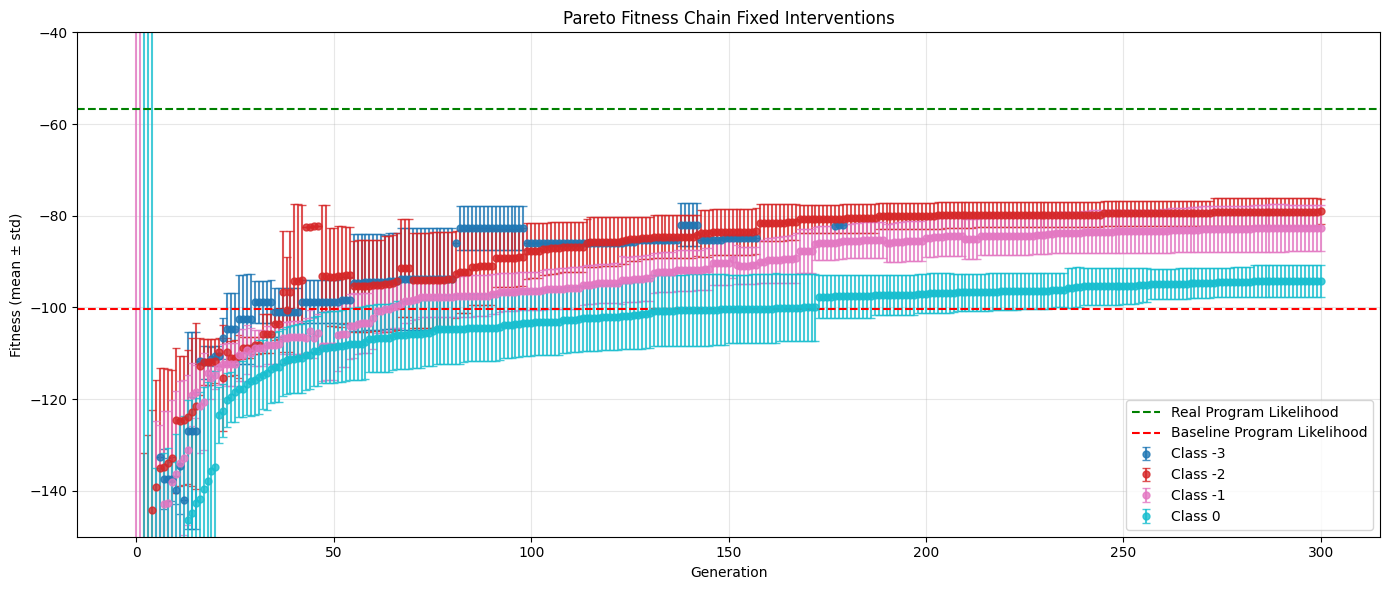

In [14]:
# Plot fitness (mean ± std) vs generation with colors corresponding to class
if pareto_stats.empty:
    print("No data to plot: no pareto_fitness.txt files found.")
else:
    fig, ax = plt.subplots(figsize=(14, 6))

    classes = sorted(pareto_stats['class'].unique())
    colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))
    color_map = {cls: colors[i] for i, cls in enumerate(classes)}

    for cls in classes:
        cls_df = pareto_stats[pareto_stats['class'] == cls]
        ax.errorbar(
            cls_df['generation'],
            cls_df['fitness_mean'],
            yerr=cls_df['fitness_std'],
            fmt='o',
            label=f'Class {cls}',
            alpha=0.8,
            markersize=5,
            color=color_map[cls],
            capsize=3,
            linestyle='None',
        )

    ax.set_xlabel('Generation')
    ax.set_ylabel('Fitness (mean ± std)')
    ax.set_title(f'Pareto Fitness {ex_name.replace("_", " ").title()}')
    ax.legend(title='Class')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-150, -40])
    #add horizontal line for likelihood of real program
    ax.axhline(y=likelihood, color='g', linestyle='--', label='Real Program Likelihood')
    ax.axhline(y=likelihood_base, color='r', linestyle='--', label='Baseline Program Likelihood')
    ax.legend()
    plt.tight_layout()
    plt.show()

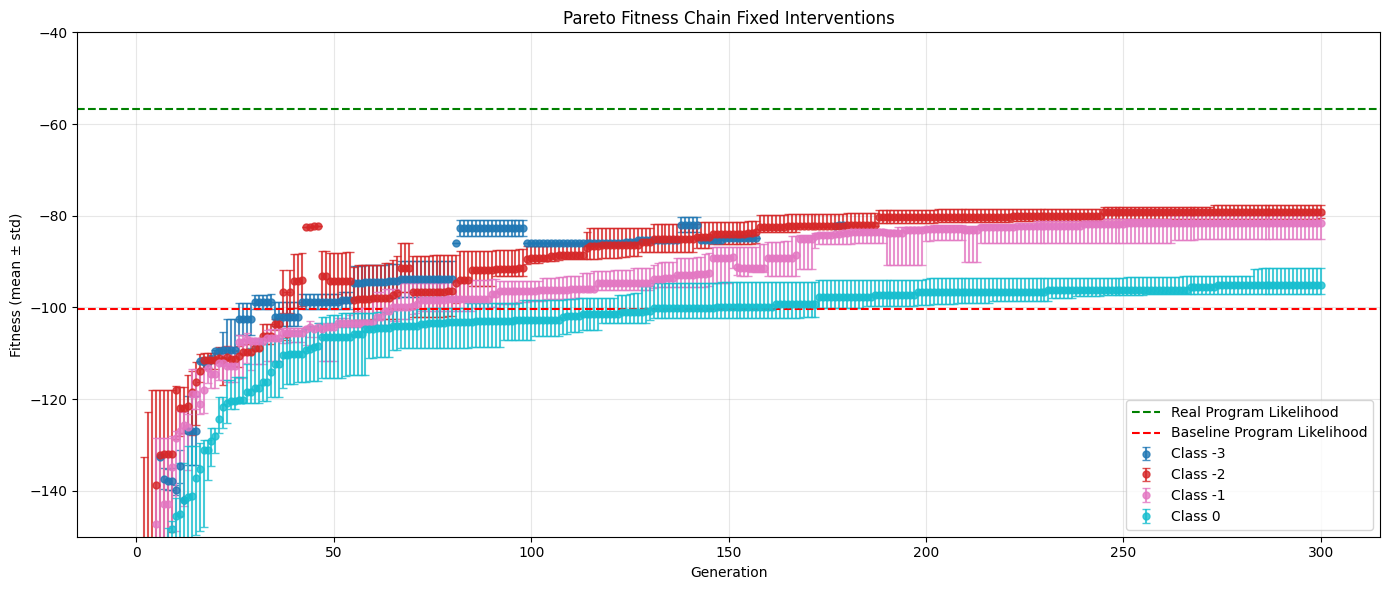

In [15]:
# Plot fitness (mean ± std) vs generation with colors corresponding to class
if pareto_stats.empty:
    print("No data to plot: no pareto_fitness.txt files found.")
else:
    fig, ax = plt.subplots(figsize=(14, 6))

    classes = sorted(pareto_stats['class'].unique())
    colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))
    color_map = {cls: colors[i] for i, cls in enumerate(classes)}

    for cls in classes:
        cls_df = pareto_stats[pareto_stats['class'] == cls]
        ax.errorbar(
            cls_df['generation'],
            cls_df['fitness_median'],
            yerr= [cls_df['fitness_median'] - cls_df['fitness_q1'], cls_df['fitness_q3'] - cls_df['fitness_median']],
            fmt='o',
            label=f'Class {cls}',
            alpha=0.8,
            markersize=5,
            color=color_map[cls],
            capsize=3,
            linestyle='None',
        )

    ax.set_xlabel('Generation')
    ax.set_ylabel('Fitness (mean ± std)')
    ax.set_title(f'Pareto Fitness {ex_name.replace("_", " ").title()}')
    ax.legend(title='Class')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-150, -40])
    #add horizontal line for likelihood of real program
    ax.axhline(y=likelihood, color='g', linestyle='--', label='Real Program Likelihood')
    ax.axhline(y=likelihood_base, color='r', linestyle='--', label='Baseline Program Likelihood')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [19]:
# using pareto_stats, for each class, generate a file txt with columns: generation, median_fitness, fitness_25perc, fitness_75perc
# separated by spaces, named 'class_' + class + '_fitness_summary'+ '.txt' and saved in ../results/synthesis/program
# with column headers: generation median_fitness fitness_25perc fitness_75perc

for cls in classes:
    cls_df = pareto_stats[pareto_stats['class'] == cls]
    output_fp = path.join('..', 'results', 'synthesis', program, f'class_{cls}_fitness_summary.txt')
    cls_df[['generation', 'fitness_median', 'fitness_q1', 'fitness_q3']].to_csv(
        output_fp,
        sep=' ',
        index=False,
        header=['generation', 'median_fitness', 'fitness_25perc', 'fitness_75perc']
    )



In [17]:
# find the folder that contains the best fitnes and in that folder open the folder first_front which contains files like 0.txt, 1.txt... and find the file
# that contains in the last row [best fitness, n] the best fitness and print the content of that file
# ...existing code...
# find the run folder that contains the best fitness, open its first_front/*.txt files,
# check the last non-empty row for [best_fitness, n] and print the matching file content
import math
from glob import glob

if pareto_fitness.empty:
    print("No pareto_fitness data available.")
else:
    best_idx = pareto_fitness['fitness'].idxmax()
    best_fitness = float(pareto_fitness.loc[best_idx, 'fitness'])
    best_runs = pareto_fitness[pareto_fitness['fitness'] == best_fitness]['run'].unique().tolist()
    print(f"Best fitness = {best_fitness}, candidate runs: {best_runs}")

    found = False
    for run in best_runs:
        run_dir = path.join(base_dir, run)
        ff_dirs = glob(path.join(run_dir, "**", "first_front"), recursive=True)
        for ff in ff_dirs:
            txt_files = sorted(glob(path.join(ff, "*.txt")))
            for txt_path in txt_files:
                with open(txt_path, "r") as f:
                    lines = [ln.strip() for ln in f if ln.strip()]
                if not lines:
                    continue
                try:
                    last_row = ast.literal_eval(lines[-1])
                except Exception:
                    continue
                if isinstance(last_row, (list, tuple)) and len(last_row) >= 1:
                    try:
                        val = float(last_row[0])
                    except Exception:
                        continue
                    if math.isclose(val, best_fitness, rel_tol=1e-9, abs_tol=1e-6):
                        print(f"Found matching file: {txt_path}")
                        print("---- file content ----")
                        print("\n".join(lines))
                        print("----------------------")
                        found = True
                        # Save the matching file content to a new file in ../results/synthesis
                        output_file = path.join('..', 'results', 'synthesis', f'{ex_name}_best_first_front.txt')
                        with open(output_file, 'w') as out_f:
                            out_f.write("\n".join(lines))
                        break
            if found:
                break
        if found:
            break

    if not found:
        print("No first_front/*.txt file found whose last row matches the best fitness.")
# ...existing code...

Best fitness = -75.79132899753081, candidate runs: ['e243-012.eduroam.tuwien.ac.at_26_1_15_103419_728198_91559_4']
Found matching file: ../results/chain_fixed_interventions/e243-012.eduroam.tuwien.ac.at_26_1_15_103419_728198_91559_4/first_front/1.txt
---- file content ----
Generation:
300
Phenotype:
1
V1 = gm([2, 47.9, 42.1], [46, 0.8, 2.4]) + gm([0, 9.6, 0], [0, 11, 5]);
V2 = 0;
V2 = V2 + uniform([4, 21.7], 2);
V3 = V2 * V2;
V3 = V3 + gm([36.3, 3.5, 11], [12.3, 50, 47], [16.9, 23, 25.8], [40.4, 15.5, 18.1]);
Pre-processed Program
:F = gm([0.041667, 0.958333], [47.9, 0.8], [42.1, 2.4]);F = F + gm([1.000000, 1.000000], [9.6, 11], [0, 5]);T = 0;T = T;T = T + uniform([4.000000, 25.700000], 2);TEMP0 = T * T;P = TEMP0;P = P;P = P + gm([0.342776, 0.116147, 0.159585, 0.381492], [3.5, 50, 23, 15.5], [11, 47, 25.8, 18.1]);Genotype:
[91, 408, 301, 321, 418, 235, 18, 90, 133, 216, 2, 443, 302, 53, 415, 348, 99, 428, 294, 403, 93, 51, 178, 71, 308, 165, 228, 329, 10, 308, 107, 96, 0, 203, 111, 338

In [18]:
# find the best file per complexity (n) in the last evolution step across all runs
import os
import re
import ast
from glob import glob

def _extract_gen_num(p: str):
    parts = p.split(os.sep)
    for part in reversed(parts):
        m = re.search(r'(?:gen|generation)[_-]?(\d+)', part, re.IGNORECASE)
        if m:
            return int(m.group(1))
        m = re.fullmatch(r'g(\d+)', part, re.IGNORECASE)
        if m:
            return int(m.group(1))
    return None

def _coerce_num(val):
    try:
        num = float(val)
    except Exception:
        return None
    if abs(num - round(num)) < 1e-9:
        return int(round(num))
    return num

if pareto_fitness.empty:
    print('No pareto_fitness data available.')
else:
    max_gen = pareto_fitness['generation'].max()
    if max_gen is not None:
        max_gen = int(max_gen)

    ff_dirs = glob(path.join(base_dir, '**', 'first_front'), recursive=True)
    if not ff_dirs:
        print('No first_front directory found under base_dir.')
    else:
        if max_gen is not None:
            filtered = [d for d in ff_dirs if _extract_gen_num(d) == max_gen]
        else:
            filtered = []
        if filtered:
            ff_dirs = filtered

        best_by_n = {}
        for ff_dir in ff_dirs:
            txt_files = sorted(glob(path.join(ff_dir, '*.txt')))
            for txt_path in txt_files:
                with open(txt_path, 'r') as f:
                    lines = [ln.strip() for ln in f if ln.strip()]
                if not lines:
                    continue
                try:
                    last_row = ast.literal_eval(lines[-1])
                except Exception:
                    continue
                if isinstance(last_row, (list, tuple)) and len(last_row) >= 2:
                    fitness = _coerce_num(last_row[0])
                    n_val = _coerce_num(last_row[1])
                    if fitness is None or n_val is None:
                        continue
                    current = best_by_n.get(n_val)
                    if current is None or fitness > current['fitness']:
                        best_by_n[n_val] = {
                            'fitness': fitness,
                            'path': txt_path,
                            'lines': lines,
                        }

        if not best_by_n:
            print('No valid first_front/*.txt files found for the last evolution step.')
        else:
            for n_val in sorted(best_by_n.keys()):
                entry = best_by_n[n_val]
                print(f'Best for n={n_val} (fitness={entry["fitness"]}): {entry["path"]}')
                print('---- file content ----')
                print('\n'.join(entry['lines']))
                print('----------------------')

                output_file = path.join('..', 'results', 'synthesis', f'{ex_name}_best_first_front_n_{n_val}.txt')
                with open(output_file, 'w') as out_f:
                    out_f.write('\n'.join(entry['lines']))


Best for n=-2 (fitness=-76.21970412216459): ../results/chain_fixed_interventions/e243-012.eduroam.tuwien.ac.at_26_1_15_103419_720614_91554_0/first_front/3.txt
---- file content ----
Generation:
300
Phenotype:
1
V1 = gm([20.9, 8.7, 2.5], [8.8, 12, 2]);
V2 = V1;
V2 = V2 + gm([26, 9, 5]);
if V2 >= 6 {
V3 = V2 - 28.1 + V2 * V2;
} else {
V3 = V2;
} end if;
V3 = V3 + gm([12, 11, 11.6], [6, 7.6, 14.8]);
Pre-processed Program
:F = gm([0.703704, 0.296296], [8.7, 12], [2.5, 2]);T = F;T = T;T = T + gm([1.000000], [9], [5]);if T >= 6 {   TEMP0 = T * T;   P = T;   P = P - 28.1;   P = P + TEMP0; } else {   P = T; } end if;P = P;P = P + gm([0.666667, 0.333333], [11, 7.6], [11.6, 14.8]);Genotype:
[290, 228, 283, 158, 185, 114, 182, 197, 377, 326, 242, 365, 212, 267, 421, 53, 202, 410, 489, 263, 160, 124, 114, 122, 2, 288, 178, 390, 86, 269, 116, 371, 366, 227, 282, 414, 26, 236, 60, 180, 260, 103, 79, 3, 411, 22, 363, 318, 423, 413, 484, 414, 14, 63, 11, 268, 421, 39, 385, 405, 474, 273, 230, 310, 299